# Source vs Target-Generated Responses for Speculative Decoding

This notebook has three jobs:

1. Run a tiny greedy speculative-decoding demo through `scripts/evaluate_sd.py` so the generated text, tokenization, acceptance metrics, throughput, and vanilla baseline are visible.
2. Explain why the response-source ablation trains on target-generated responses instead of only the static dataset responses.
3. Use the recorded Qwen2.5 source-vs-target-generated results directly, then derive comparison tables, effect sizes, rankings, and visualizations without loading checkpoints or running extra evaluations.


## 1. Environment and Backend

The RunAI vLLM environment is expected at `/scratch/venvs/kdsd-vllm`. If this notebook is opened from another kernel, the demo falls back to the manual HF backend. The final comparison section uses fixed recorded numbers and does not need vLLM.

In [46]:
from __future__ import annotations

import json
import math
import os
import re
import subprocess
import sys
import time
from pathlib import Path
from typing import Any

try:
    import pandas as pd
except Exception as exc:
    pd = None
    print(f"WARNING: pandas is unavailable; tables will use plain Markdown. ({exc})")

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = print

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO)

SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

default_hf_home = "/scratch/hf_cache" if Path("/scratch").exists() else str(REPO / ".cache" / "huggingface")
os.environ.setdefault("HF_HOME", default_hf_home)
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")
try:
    Path(os.environ["HF_HOME"]).mkdir(parents=True, exist_ok=True)
except OSError as exc:
    print(f"WARNING: could not create HF_HOME={os.environ['HF_HOME']}: {exc}")

KDSD_VLLM_VENV = Path("/scratch/venvs/kdsd-vllm")
active_executable = Path(sys.executable).resolve()
active_virtual_env = os.environ.get("VIRTUAL_ENV")
active_virtual_env_path = Path(active_virtual_env).resolve() if active_virtual_env else None
in_kdsd_vllm_env = str(active_executable).startswith(str(KDSD_VLLM_VENV)) or active_virtual_env_path == KDSD_VLLM_VENV

try:
    import vllm  # noqa: F401
    vllm_import_ok = True
    vllm_version = getattr(vllm, "__version__", "unknown")
except Exception as exc:
    vllm_import_ok = False
    vllm_version = f"unavailable: {type(exc).__name__}: {exc}"

DEMO_EVAL_BACKEND = "vllm" if in_kdsd_vllm_env and vllm_import_ok else "manual"
if DEMO_EVAL_BACKEND != "vllm":
    print("WARNING: active kernel is not the /scratch/venvs/kdsd-vllm vLLM environment, or vLLM cannot be imported.")
    print("         Demo cells will use eval.backend=manual. Final saved-result comparison is unaffected.")

print("repo root          :", REPO)
print("python executable  :", active_executable)
print("VIRTUAL_ENV        :", active_virtual_env_path)
print("HF_HOME            :", os.environ["HF_HOME"])
print("vLLM env expected  :", KDSD_VLLM_VENV)
print("in vLLM env        :", in_kdsd_vllm_env)
print("vLLM import        :", vllm_import_ok, vllm_version)
print("demo eval backend  :", DEMO_EVAL_BACKEND)


         Demo cells will use eval.backend=manual. Final saved-result comparison is unaffected.
repo root          : /scratch/cs552-repos/cs552-kdsd-youyang
python executable  : /usr/bin/python3.12
VIRTUAL_ENV        : None
HF_HOME            : /scratch/hf_cache
vLLM env expected  : /scratch/venvs/kdsd-vllm
in vLLM env        : False
vLLM import        : True 0.11.0
demo eval backend  : manual


In [47]:
try:
    subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.free", "--format=csv"],
        check=False,
    )
except FileNotFoundError:
    print("nvidia-smi not found; this is expected outside the RunAI GPU pod.")


name, memory.total [MiB], memory.free [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 38858 MiB


## 2. Tiny Greedy Speculative-Decoding Demo

This section calls `scripts/evaluate_sd.py` on one prompt with the pretrained Qwen2.5 draft. It runs greedy decoding, `gamma=4`, `max_new_tokens=64`, and includes a vanilla target-only baseline for speedup. The command writes normal eval artifacts under `DEMO_RESULTS_DIR`.


In [48]:
RUN_DEMO_EVAL = True
FORCE_DEMO_RERUN = True

DEMO_RUN_NAME = "notebook_qwen25_pretrained_greedy_demo"
DEMO_PROMPT = "Explain speculative decoding in two concise sentences."
DEMO_GAMMA = 4
DEMO_MAX_NEW_TOKENS = 64
DEMO_N_WARMUP = 0
DEMO_N_REPEATS = 1

demo_scratch_root = Path("/scratch/cs552-results")
DEMO_RESULTS_DIR = demo_scratch_root / DEMO_RUN_NAME if demo_scratch_root.parent.exists() else REPO / "outputs" / "notebook-demo-results" / DEMO_RUN_NAME
DEMO_PROMPT_JSONL = Path("/tmp/kdsd_notebook_demo_prompt.jsonl")
DEMO_PROMPT_JSONL.write_text(
    json.dumps({"id": "demo-0", "prompt_text": DEMO_PROMPT, "response_text": "", "source": "notebook"}) + "\n",
    encoding="utf-8",
)

demo_overrides = [
    "model=qwen25",
    f"run_name={DEMO_RUN_NAME}",
    "draft=pretrained",
    f"prompts.jsonl={DEMO_PROMPT_JSONL}",
    "prompts.hf_dataset=null",
    "prompts.limit=1",
    "runtime.mode=greedy",
    "runtime.temperature=0.0",
    "runtime.top_p=1.0",
    f"runtime.gamma={DEMO_GAMMA}",
    f"runtime.max_new_tokens={DEMO_MAX_NEW_TOKENS}",
    f"eval.backend={DEMO_EVAL_BACKEND}",
    f"eval.n_warmup={DEMO_N_WARMUP}",
    f"eval.n_repeats={DEMO_N_REPEATS}",
    "eval.run_vanilla_baseline=true",
    "wandb.enabled=false",
    f"results_dir={DEMO_RESULTS_DIR}",
    f"hydra.run.dir={REPO / 'outputs' / 'notebook-demo' / DEMO_RUN_NAME}",
]

print("prompt file :", DEMO_PROMPT_JSONL)
print("results dir :", DEMO_RESULTS_DIR)
print("overrides   :")
for item in demo_overrides:
    print(" ", item)


prompt file : /tmp/kdsd_notebook_demo_prompt.jsonl
results dir : /scratch/cs552-results/notebook_qwen25_pretrained_greedy_demo
overrides   :
  model=qwen25
  run_name=notebook_qwen25_pretrained_greedy_demo
  draft=pretrained
  prompts.jsonl=/tmp/kdsd_notebook_demo_prompt.jsonl
  prompts.hf_dataset=null
  prompts.limit=1
  runtime.mode=greedy
  runtime.temperature=0.0
  runtime.top_p=1.0
  runtime.gamma=4
  runtime.max_new_tokens=64
  eval.backend=manual
  eval.n_warmup=0
  eval.n_repeats=1
  eval.run_vanilla_baseline=true
  wandb.enabled=false
  results_dir=/scratch/cs552-results/notebook_qwen25_pretrained_greedy_demo
  hydra.run.dir=/scratch/cs552-repos/cs552-kdsd-youyang/outputs/notebook-demo/notebook_qwen25_pretrained_greedy_demo


In [49]:
summary_path = DEMO_RESULTS_DIR / "eval_summary.json"
if not RUN_DEMO_EVAL:
    print("RUN_DEMO_EVAL=False; skipping the live demo run.")
elif summary_path.exists() and not FORCE_DEMO_RERUN:
    print(f"Reusing cached demo summary: {summary_path}")
else:
    cmd = [sys.executable, str(REPO / "scripts" / "evaluate_sd.py"), *demo_overrides]
    print("$ " + " ".join(str(part) for part in cmd), flush=True)
    started = time.perf_counter()
    proc = subprocess.Popen(
        cmd,
        cwd=str(REPO),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="", flush=True)
    rc = proc.wait()
    elapsed = time.perf_counter() - started
    print(f"\nexit code: {rc}; elapsed_s={elapsed:.1f}")
    if rc != 0:
        raise RuntimeError(f"evaluate_sd.py failed with exit code {rc}")


$ /usr/bin/python3 /scratch/cs552-repos/cs552-kdsd-youyang/scripts/evaluate_sd.py model=qwen25 run_name=notebook_qwen25_pretrained_greedy_demo draft=pretrained prompts.jsonl=/tmp/kdsd_notebook_demo_prompt.jsonl prompts.hf_dataset=null prompts.limit=1 runtime.mode=greedy runtime.temperature=0.0 runtime.top_p=1.0 runtime.gamma=4 runtime.max_new_tokens=64 eval.backend=manual eval.n_warmup=0 eval.n_repeats=1 eval.run_vanilla_baseline=true wandb.enabled=false results_dir=/scratch/cs552-results/notebook_qwen25_pretrained_greedy_demo hydra.run.dir=/scratch/cs552-repos/cs552-kdsd-youyang/outputs/notebook-demo/notebook_qwen25_pretrained_greedy_demo
2026-06-10 14:37:08,557 INFO    kdsd.evaluate_sd :: Using cached pretrained draft checkpoint at /scratch/cs552-repos/cs552-kdsd-youyang/checkpoints/pretrained/qwen-qwen2.5-0.5b-instruct-4b05be1db9/model
2026-06-10 14:37:08,564 INFO    kdsd.evaluate_sd :: resolved config:
model:
  target: Qwen/Qwen2.5-3B-Instruct
  draft_default: Qwen/Qwen2.5-0.5B-Ins

In [50]:
def read_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as fh:
        value = json.load(fh)
    return value if isinstance(value, dict) else {}


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows = []
    with path.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


summary = read_json(DEMO_RESULTS_DIR / "eval_summary.json")
generations = read_jsonl(DEMO_RESULTS_DIR / "generations.jsonl")
first = generations[0] if generations else {}

metric_keys = [
    "acceptance_rate",
    "avg_accepted_tokens",
    "tokens_per_second",
    "speedup",
    "sd_time_s",
    "vanilla_time_s",
    "n_prompts",
    "n_warmup",
    "n_repeats",
]
print("Demo metrics")
for key in metric_keys:
    print(f"{key:24s} {summary.get(key)}")

print("\nEngine metrics")
print(json.dumps(summary.get("engines", {}), indent=2)[:4000])

print("\nPrompt")
print(first.get("prompt", ""))
print("\nGeneration")
print(first.get("generation", ""))
print("\naccepted_lens:", first.get("accepted_lens"))
if not first.get("accepted_lens") and "vllm" in (summary.get("engines") or {}):
    print("Note: vLLM exposes aggregate speculative counters, not per-prompt accepted_lens; see engines.vllm above.")

try:
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(summary.get("target", "Qwen/Qwen2.5-3B-Instruct"), trust_remote_code=False)
    token_ids = tokenizer(first.get("generation", ""), add_special_tokens=False).input_ids
    token_strings = tokenizer.convert_ids_to_tokens(token_ids)
    print("\nOutput token ids (first 80):")
    print(token_ids[:80])
    print("\nOutput token strings (first 80):")
    print(token_strings[:80])
except Exception as exc:
    print(f"WARNING: could not tokenize the generated text for display: {exc}")


Demo metrics
acceptance_rate          0.25
avg_accepted_tokens      1.0
tokens_per_second        10.218304287065292
speedup                  0.28495077718779394
sd_time_s                3.5230894470005296
vanilla_time_s           1.003907076024916
n_prompts                1
n_warmup                 0
n_repeats                1

Engine metrics
{
  "hf": {
    "sd_time_s": 3.5230894470005296,
    "vanilla_time_s": 1.003907076024916,
    "tokens_per_second": 10.218304287065292,
    "speedup": 0.28495077718779394,
    "acceptance_rate": 0.25,
    "avg_accepted_tokens": 1.0,
    "n_outer_steps": 19,
    "target_calls": 38,
    "draft_calls": 95,
    "draft_forward_s": 1.7749786586761476,
    "target_forward_s": 1.6034197559356689,
    "batched": false
  }
}

Prompt
Explain speculative decoding in two concise sentences.

Generation
Speculative decoding is a technique where data is decoded as if it were valid, even before all validation checks are complete, to improve performance by reducing 

## 3. Why Target-Generated Responses?

The source-vs-target response ablation changes the training responses, not the prompts. In the static/source condition, KD or CE training reads the original UltraChat response text. In the target-generated condition, `configs/data/ultrachat_50k_target_gen.yaml` points `train_path` and `val_path` at cached responses written by `scripts/generate_target_responses.py`.

The cache is generated by the target model itself. The current config defaults use greedy decoding with `temperature=0.0`, `top_p=1.0`, and `max_new_tokens=512`; the script can run through vLLM or HF, but the saved JSONL contract stays the same.

The live demo above shows the runtime side of that agreement: accepted draft tokens are the tokens the target verifies without falling back to target-only decoding. For speculative decoding, the draft is useful when it proposes tokens that the target will accept. Target-generated responses are therefore a better theoretical fit for KD acceleration than arbitrary static responses: the draft is trained on the teacher's own decoding distribution, including its preferred phrasing, token boundaries, and continuation style. That should raise draft-target agreement during runtime rejection sampling, which is exactly what acceptance rate, average accepted tokens, throughput, and speedup measure.


## 4. Fixed Experiment Results

The remaining cells intentionally avoid checkpoint loading, training, and extra evaluation. They use the recorded result table for `Qwen2.5-3B-Instruct / Qwen2.5-0.5B-Instruct` directly, then analyze how response source changes speculative-decoding acceptance and speedup.

In [59]:
PAIR_LABEL = "Qwen2.5-3B-Instruct / Qwen2.5-0.5B-Instruct"

DIRECT_RESULTS = [
    {"loss": "Pretrained", "source": "Original Data", "acc": 0.450, "avg_tok": 1.801, "speedup": 0.508},
    {"loss": "Pretrained", "source": "Target-Generated Data", "acc": 0.454, "avg_tok": 1.820, "speedup": 0.504},
    {"loss": "FKL", "source": "Original Data", "acc": 0.451, "avg_tok": 1.804, "speedup": 0.509},
    {"loss": "FKL", "source": "Target-Generated Data", "acc": 0.472, "avg_tok": 1.890, "speedup": 0.531},
    {"loss": "RKL", "source": "Original Data", "acc": 0.472, "avg_tok": 1.888, "speedup": 0.521},
    {"loss": "RKL", "source": "Target-Generated Data", "acc": 0.463, "avg_tok": 1.850, "speedup": 0.527},
    {"loss": "JSD", "source": "Original Data", "acc": 0.471, "avg_tok": 1.886, "speedup": 0.524},
    {"loss": "JSD", "source": "Target-Generated Data", "acc": 0.492, "avg_tok": 1.970, "speedup": 0.541},
]

print("pair   :", PAIR_LABEL)
print("rows   :", len(DIRECT_RESULTS))


pair   : Qwen2.5-3B-Instruct / Qwen2.5-0.5B-Instruct
rows   : 8


In [52]:
def is_number(value: Any) -> bool:
    return isinstance(value, (int, float)) and not isinstance(value, bool) and math.isfinite(float(value))


def fmt_value(value: Any) -> str:
    if value is None:
        return ""
    if is_number(value):
        return f"{float(value):.3f}"
    return str(value)


def show_rows(rows: list[dict[str, Any]], columns: list[str], title: str) -> None:
    print(f"\n{title}")
    if pd is not None:
        display(pd.DataFrame(rows).reindex(columns=columns))
        return
    if not rows:
        print("No rows.")
        return
    table = ["| " + " | ".join(columns) + " |", "| " + " | ".join("---" for _ in columns) + " |"]
    for row in rows:
        table.append("| " + " | ".join(fmt_value(row.get(col)) for col in columns) + " |")
    if Markdown is not None:
        display(Markdown("\n".join(table)))
    else:
        print("\n".join(table))


def pivot_result_rows(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    losses = []
    for row in rows:
        if row["loss"] not in losses:
            losses.append(row["loss"])
    out = []
    for loss in losses:
        original = next(row for row in rows if row["loss"] == loss and row["source"] == "Original Data")
        target = next(row for row in rows if row["loss"] == loss and row["source"] == "Target-Generated Data")
        out.append(
            {
                "KD Loss": loss,
                "Original Acc.": original["acc"],
                "Original Avg. Tok.": original["avg_tok"],
                "Original Speedup": original["speedup"],
                "Target Acc.": target["acc"],
                "Target Avg. Tok.": target["avg_tok"],
                "Target Speedup": target["speedup"],
            }
        )
    return out


table4_rows = pivot_result_rows(DIRECT_RESULTS)
show_rows(
    table4_rows,
    [
        "KD Loss",
        "Original Acc.",
        "Original Avg. Tok.",
        "Original Speedup",
        "Target Acc.",
        "Target Avg. Tok.",
        "Target Speedup",
    ],
    "Table 4: Effect of response sources",
)



Table 4: Effect of response sources


,KD Loss,Original Acc.,Original Avg. Tok.,Original Speedup,Target Acc.,Target Avg. Tok.,Target Speedup
0,Pretrained,0.450,1.801,0.508,0.454,1.82,0.504
1,FKL,0.451,1.804,0.509,0.472,1.89,0.531
2,RKL,0.472,1.888,0.521,0.463,1.85,0.527
3,JSD,0.471,1.886,0.524,0.492,1.97,0.541


In [53]:
delta_rows = []
for row in table4_rows:
    delta_acc = row["Target Acc."] - row["Original Acc."]
    delta_tok = row["Target Avg. Tok."] - row["Original Avg. Tok."]
    delta_speedup = row["Target Speedup"] - row["Original Speedup"]
    delta_rows.append(
        {
            "KD Loss": row["KD Loss"],
            "Delta Acc.": delta_acc,
            "Delta Avg. Tok.": delta_tok,
            "Delta Speedup": delta_speedup,
            "Rel. Acc. Gain %": 100.0 * delta_acc / row["Original Acc."],
            "Rel. Speedup Gain %": 100.0 * delta_speedup / row["Original Speedup"],
            "Target Better Acc.": delta_acc > 0,
            "Target Better Speedup": delta_speedup > 0,
        }
    )

show_rows(
    delta_rows,
    [
        "KD Loss",
        "Delta Acc.",
        "Delta Avg. Tok.",
        "Delta Speedup",
        "Rel. Acc. Gain %",
        "Rel. Speedup Gain %",
        "Target Better Acc.",
        "Target Better Speedup",
    ],
    "Target-generated minus original",
)



Target-generated minus original


,KD Loss,Delta Acc.,Delta Avg. Tok.,Delta Speedup,Rel. Acc. Gain %,Rel. Speedup Gain %,Target Better Acc.,Target Better Speedup
0,Pretrained,0.004,0.019,-0.004,0.888889,-0.787402,True,False
1,FKL,0.021,0.086,0.022,4.656319,4.322200,True,True
2,RKL,-0.009,-0.038,0.006,-1.906780,1.151631,False,True
3,JSD,0.021,0.084,0.017,4.458599,3.244275,True,True


Pair: Qwen2.5-3B-Instruct / Qwen2.5-0.5B-Instruct

Among fine-tuned KD losses, target-generated responses change acceptance by +0.011 on average.
They change average accepted tokens by +0.044 and speedup by +0.015 on average.

- Best target-generated speedup: JSD with 0.541x.
- Best target-generated acceptance: JSD with 0.492.

## 5. Study conclusions

- JSD with target-generated responses is the strongest row in the recorded table: highest acceptance, highest average accepted tokens, and highest speedup.
- FKL benefits clearly from target-generated responses on all three reported metrics.
- RKL is a useful exception to inspect: target-generated data lowers acceptance and average accepted tokens versus original data, but speedup still increases slightly.
- Pretrained is almost unchanged across the two columns, which is expected because no response-source training signal is applied.

## 6. Visualizations

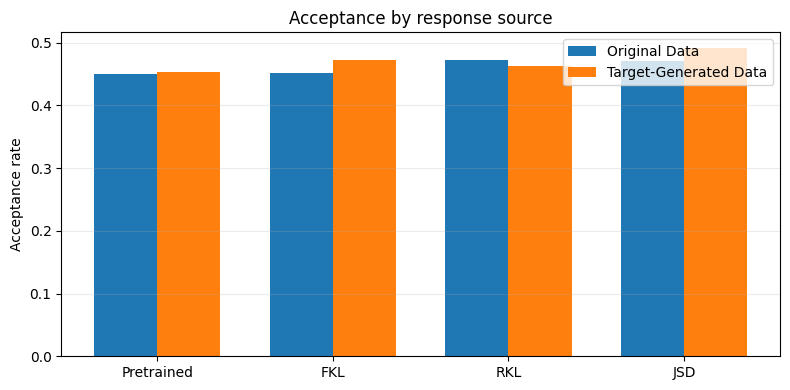

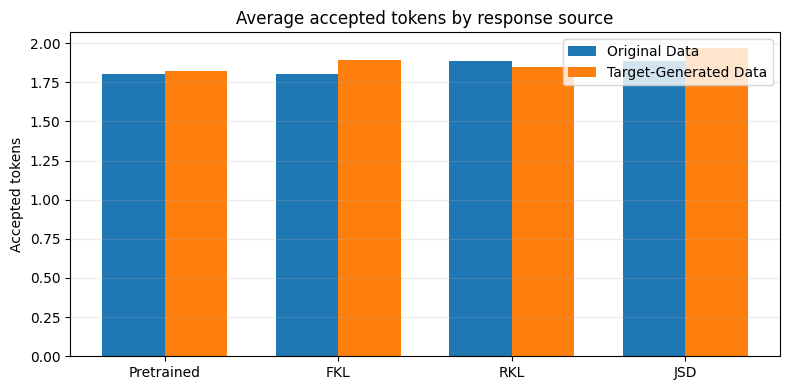

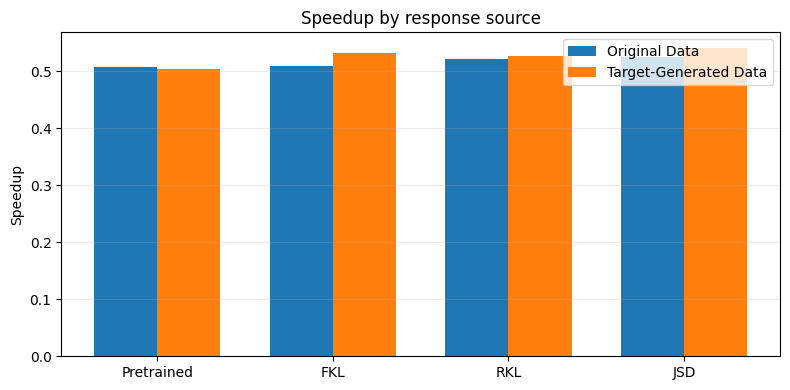

In [56]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f"WARNING: matplotlib unavailable; skipping plots. ({exc})")

def ascii_bar(value: float, *, lo: float, hi: float, width: int = 24) -> str:
    if hi <= lo:
        filled = width
    else:
        filled = round(width * (value - lo) / (hi - lo))
    filled = max(0, min(width, filled))
    return "#" * filled + "." * (width - filled)


def show_text_grouped_metric(original_key: str, target_key: str, title: str) -> None:
    values = [row[original_key] for row in table4_rows] + [row[target_key] for row in table4_rows]
    lo, hi = min(values), max(values)
    rows = []
    for row in table4_rows:
        rows.append(
            {
                "KD Loss": row["KD Loss"],
                "Original": row[original_key],
                "Original Bar": ascii_bar(row[original_key], lo=lo, hi=hi),
                "Target": row[target_key],
                "Target Bar": ascii_bar(row[target_key], lo=lo, hi=hi),
            }
        )
    show_rows(rows, ["KD Loss", "Original", "Original Bar", "Target", "Target Bar"], title)



def row_for_loss(loss: str) -> dict[str, Any]:
    return next(row for row in table4_rows if row["KD Loss"] == loss)


def plot_grouped_metric(original_key: str, target_key: str, ylabel: str, title: str) -> None:
    if plt is None:
        return
    losses = [row["KD Loss"] for row in table4_rows]
    x = list(range(len(losses)))
    width = 0.36
    original_values = [row[original_key] for row in table4_rows]
    target_values = [row[target_key] for row in table4_rows]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([pos - width / 2 for pos in x], original_values, width=width, label="Original Data")
    ax.bar([pos + width / 2 for pos in x], target_values, width=width, label="Target-Generated Data")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(losses)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_grouped_metric("Original Acc.", "Target Acc.", "Acceptance rate", "Acceptance by response source")
plot_grouped_metric("Original Avg. Tok.", "Target Avg. Tok.", "Accepted tokens", "Average accepted tokens by response source")
plot_grouped_metric("Original Speedup", "Target Speedup", "Speedup", "Speedup by response source")

if plt is None:
    show_text_grouped_metric("Original Acc.", "Target Acc.", "Acceptance by response source")
    show_text_grouped_metric("Original Avg. Tok.", "Target Avg. Tok.", "Average accepted tokens by response source")
    show_text_grouped_metric("Original Speedup", "Target Speedup", "Speedup by response source")


## 7. Delta Plot

This plot focuses on effect size: target-generated minus original. Positive bars mean target-generated response training improved the metric.

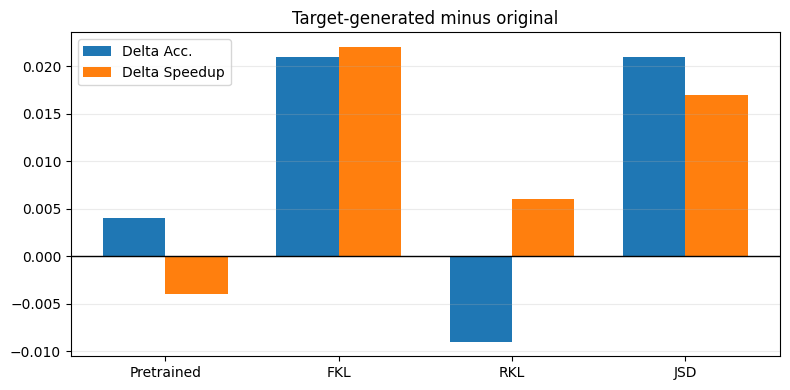

In [57]:
if plt is not None:
    losses = [row["KD Loss"] for row in delta_rows]
    x = list(range(len(losses)))
    width = 0.36
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axhline(0.0, color="black", linewidth=1)
    ax.bar([pos - width / 2 for pos in x], [row["Delta Acc."] for row in delta_rows], width=width, label="Delta Acc.")
    ax.bar([pos + width / 2 for pos in x], [row["Delta Speedup"] for row in delta_rows], width=width, label="Delta Speedup")
    ax.set_title("Target-generated minus original")
    ax.set_xticks(x)
    ax.set_xticklabels(losses)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    max_abs = max(abs(row["Delta Acc."]) for row in delta_rows + [{"Delta Acc.": 0.0}])
    max_abs = max(max_abs, max(abs(row["Delta Speedup"]) for row in delta_rows + [{"Delta Speedup": 0.0}]))
    delta_text_rows = []
    for row in delta_rows:
        delta_text_rows.append(
            {
                "KD Loss": row["KD Loss"],
                "Delta Acc.": row["Delta Acc."],
                "Acc. Bar": ascii_bar(abs(row["Delta Acc."]), lo=0.0, hi=max_abs),
                "Delta Speedup": row["Delta Speedup"],
                "Speedup Bar": ascii_bar(abs(row["Delta Speedup"]), lo=0.0, hi=max_abs),
            }
        )
    show_rows(delta_text_rows, ["KD Loss", "Delta Acc.", "Acc. Bar", "Delta Speedup", "Speedup Bar"], "Absolute delta bars")


## 8. Acceptance-Speedup Relationship

A small scatter plot helps separate acceptance improvements from speedup improvements. RKL is the interesting outlier: target-generated data has lower acceptance, but slightly higher speedup in the recorded table.

**Future work:** check whether RKL's speedup gain with lower acceptance comes from timing variance, accepted-position distribution, or a different generated-token count.

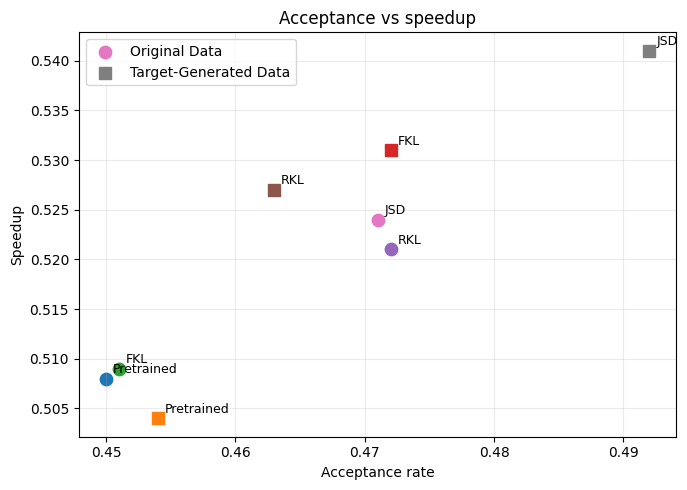

In [58]:
if plt is not None:
    marker_by_source = {"Original Data": "o", "Target-Generated Data": "s"}
    fig, ax = plt.subplots(figsize=(7, 5))
    for row in DIRECT_RESULTS:
        ax.scatter(row["acc"], row["speedup"], marker=marker_by_source[row["source"]], s=80, label=row["source"])
        ax.annotate(row["loss"], (row["acc"], row["speedup"]), textcoords="offset points", xytext=(5, 4), fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys())
    ax.set_title("Acceptance vs speedup")
    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Speedup")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    relationship_rows = sorted(
        [
            {"loss": row["loss"], "source": row["source"], "acc": row["acc"], "speedup": row["speedup"]}
            for row in DIRECT_RESULTS
        ],
        key=lambda row: (row["speedup"], row["acc"]),
        reverse=True,
    )
    show_rows(relationship_rows, ["loss", "source", "acc", "speedup"], "Acceptance-speedup ranking")


# Individual contributions

1. Implement training and evaluation pipeline: all the speculative decoding evaluation, training with different loss interface support, wandb logging reports, config resolution, evaluation result storage formats.
2. Implement the target generation with VLLM support, upgrade VLLM for speculative decoding on 'draft' mode. Add vllm evaluation mode besides manual implementation of SD.
3. Experiment with data source study: original prompts + static data v.s. original prompts + target generated data (cached in files)
4. Transfer Qwen2.5 family to Qwen3 family for larger model size gap with initial speedup experiments to prove the effectiveness.
5. Collaborate with other teammates for report writing.